# 学習なしループを1ステップずつ実証する

会話記録の最後で説明した仕組み **「種 → 広げる → 確かめる → 分ける」** を、
関節リウマチ（RA）の18遺伝子デモで順番に実行します。

- 既定では、会話記録で Claude が判定した答えを**記録から再生**します（外部通信なし）。
- 下の `MODEL_PATH` に TxGemma などの GGUF ファイルを指定すると、**同じ手順を本物のLLMで**実行します。
- 各セルは上から順に実行してください（前のセルの結果を使います）。

> 注意：記録の答えは Claude が5段階の確信度で判定したもので、臨床結果を知っている「後知恵」が混ざっています。
> このノートは**手順が設計どおりに動くこと**を示すもので、性能の証明ではありません。

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))          # notebooks/ から実行する前提
import pandas as pd
from dataclasses import asdict
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

from target_loop.config import ScoringRules, DEFAULT_RULES, QUESTIONS, QUESTION_BY_ID
from target_loop.models import Candidate, Category
from target_loop.backends import RecordedBackend
from target_loop.scoring import score_candidate
from target_loop.pairwise import pairwise_rank, ranking_string
from target_loop.loop import TargetLoop
from target_loop.report import to_markdown
from demo.ra_demo import CHAIN, SEEDS_PROPOSED, ANSWERS, build_record
print("import ok")

import ok


## バックエンドの選択

`MODEL_PATH = None` なら記録の再生、パスを入れれば llama.cpp で GGUF を動かします。

In [2]:
MODEL_PATH = None          # 例: os.path.expanduser("~/models/txgemma-9b-chat-Q6_K.gguf")

if MODEL_PATH and os.path.exists(MODEL_PATH):
    from target_loop.backends import LlamaCppBackend
    backend = LlamaCppBackend(MODEL_PATH, n_ctx=1024, n_gpu_layers=-1)
    print("backend: llama.cpp", MODEL_PATH)
else:
    backend = RecordedBackend(build_record())
    print("backend: recorded (Claude-judged demo answers)")

rules = DEFAULT_RULES
loop = TargetLoop(backend, CHAIN, rules)

backend: recorded (Claude-judged demo answers)


## ステップ0：点数のルールを先に決めて固定する（学習なし）

```
Q = 質問の「はい」確率の平均（副作用 Q5 は 1−p）
P = max( M, 0.8×N, 0.6×V )
総合 = Q × P × 0.7^(回数−1)
逆向き・矛盾 → 別枠
```

In [3]:
pd.DataFrame(asdict(rules).items(), columns=["rule", "value"])

,rule,value
0,moa_same_stage,1.0
1,moa_adjacent,0.7
2,moa_off_chain,0.0
3,network_direct,1.0
4,network_two_hop,0.5
5,network_far,0.0
6,network_weight,0.8
7,vector_near,1.0
8,vector_mid,0.5
9,vector_far,0.0


In [4]:
pd.DataFrame([{"qid": q.qid, "invert": q.invert, "question": q.text} for q in QUESTIONS])

,qid,invert,question
0,Q1,False,Is the gene {gene} expressed or active in the ...
1,Q2,False,Is {gene} part of the disease mechanism chain ...
2,Q3,False,Would inhibiting {gene} be expected to improve...
3,Q4,False,"Is {gene} a druggable protein class (enzyme, r..."
4,Q5,True,Would inhibiting {gene} be expected to cause s...
5,Q6,False,Do common or rare genetic variants in {gene} a...


## ステップ1：作用のしくみの鎖と、種を作る

種は LLM に挙げさせた後、**「その標的の承認薬は？」→「その薬が結合する分子は？」** と逆向きに確認します。
デモでは CTLA4 が挙がりましたが、アバタセプトが結合するのは CD80/CD86 なので CD80 に直されます。

In [5]:
display(pd.DataFrame([{"stage": s.sid, "content": s.name} for s in CHAIN.stages]))

seeds, seed_notes = loop.build_seeds(SEEDS_PROPOSED)
print("proposed:", SEEDS_PROPOSED)
print("validated:", seeds)
for n in seed_notes: print(" -", n)

cands = {}
for s in seeds:
    c = Candidate(symbol=s, round_found=0, is_seed=True, how_found="seed", network_hops=0,
                  vector_bin="near", verified_known=True)
    c.stage, c.direction = loop.stage_of(s), loop.direction_of(s)
    cands[s] = c
seed_stages = [cands[s].stage for s in seeds if cands[s].stage]
known = set(seeds)
pd.DataFrame([{"seed": s, "stage": cands[s].stage, "direction": cands[s].direction.value} for s in seeds])

,stage,content
0,S1,antigen presentation and T-cell activation
1,S2,B cells and autoantibodies
2,S3,innate immune signalling
3,S4,inflammatory cytokines and their receptors
4,S5,intracellular signalling (JAK-STAT)
5,S6,synovial proliferation and osteoclast activation
6,S7,joint destruction (symptom)


proposed: ['CTLA4', 'MS4A1', 'TNF', 'IL6R', 'JAK1']
validated: ['CD80', 'MS4A1', 'TNF', 'IL6R', 'JAK1']
 - CTLA4: corrected to CD80 (drug abatacept binds CD80, CD86)


,seed,stage,direction
0,CD80,S1,worse
1,MS4A1,S2,worse
2,TNF,S4,worse
3,IL6R,S4,worse
4,JAK1,S5,worse


## ステップ2：3種類の「近さ」で候補を広げる（1回目）

直接の相手（1段）、上流・下流（2段）、同じ段階（2段）、地図の隣人（2段）を LLM に挙げさせます。

In [6]:
new1 = loop.expand(seeds, cands, round_no=1, known=known)
pd.DataFrame([{"gene": c.symbol, "found via": c.how_found, "hops": c.network_hops} for c in new1])

,gene,found via,hops
0,BTK,MS4A1 -> same stage S2 -> BTK,2
1,TNFRSF1A,TNF -> direct partner -> TNFRSF1A,1
2,IRAK4,TNF -> upstream regulator -> IRAK4,2
3,TNFSF11,TNF -> downstream effector -> TNFSF11,2
4,CSF2,TNF -> same stage S4 -> CSF2,2
5,IL17A,TNF -> same stage S4 -> IL17A,2
6,IL10,TNF -> same stage S4 -> IL10,2
7,IL6,IL6R -> direct partner -> IL6,1
8,IL11,IL6R -> map neighbour (same family) -> IL11,2
9,TYK2,JAK1 -> direct partner -> TYK2,1


## ステップ3：質問と回答をくり返して採点する

1問につき **言い換え3通り × 選択肢の順2通り = 6回** 聞いて平均します。まず1遺伝子（TNFSF11 = RANKL）の生のやり取りを見ます。

In [7]:
gene = "TNFSF11"
rows = []
for qid in loop.qids:
    q = QUESTION_BY_ID[qid]
    for t in (q.text,) + tuple(q.paraphrases):
        for order in ("yes_first", "no_first"):
            rows.append({"qid": qid, "order": order, "p_yes": backend.yes_probability(loop.fmt(t, gene=gene), order),
                         "prompt": loop.fmt(t, gene=gene)[:90] + "…"})
df = pd.DataFrame(rows)
display(df)
print("averaged:", {qid: round(loop.ask(qid, gene), 3) for qid in loop.qids})

,qid,order,p_yes,prompt
0,Q1,yes_first,1.00,Is the gene TNFSF11 expressed or active in the...
1,Q1,no_first,1.00,Is the gene TNFSF11 expressed or active in the...
2,Q1,yes_first,1.00,Is TNFSF11 up-regulated or functionally active...
3,Q1,no_first,1.00,Is TNFSF11 up-regulated or functionally active...
4,Q1,yes_first,1.00,"In rheumatoid arthritis, does the gene TNFSF11..."
5,Q1,no_first,1.00,"In rheumatoid arthritis, does the gene TNFSF11..."
6,Q2,yes_first,1.00,Is TNFSF11 part of the disease mechanism chain...
7,Q2,no_first,1.00,Is TNFSF11 part of the disease mechanism chain...
8,Q2,yes_first,1.00,Does TNFSF11 act at a defined step of the path...
9,Q2,no_first,1.00,Does TNFSF11 act at a defined step of the path...


averaged: {'Q1': 1.0, 'Q2': 1.0, 'Q3': 1.0, 'Q4': 1.0, 'Q5': 0.25}


In [8]:
for c in new1:
    loop.annotate(c, seeds)      # stage, direction, vector bin, Q1..Q5
    loop.verify(c)               # reverse questions: approved drug? stage consistent?
for c in cands.values():
    if c.is_seed:
        for qid in loop.qids: c.answers.setdefault(qid, 1.0)
    score_candidate(c, CHAIN, seed_stages, rules, loop.qids)
    if c.verified_known and not c.is_seed: known.add(c.symbol)

def score_table(cands):
    rows = []
    for c in sorted(cands.values(), key=lambda c: (-(c.total or -1), c.symbol)):
        if c.is_seed: continue
        rows.append({"gene": c.symbol, "round": c.round_found, "stage": c.stage, "dir": c.direction.value,
                     "M": c.m_score, "N": c.n_score, "V": c.v_score,
                     **{q: round(c.answers.get(q, float('nan')), 2) for q in loop.qids},
                     "Q": c.q_score, "P": c.p_score, "total": c.total, "category": c.category.value,
                     "note": c.exclusion_reason or c.verification_note.strip()})
    return pd.DataFrame(rows)
score_table(cands)

,gene,round,stage,dir,M,N,V,Q1,Q2,Q3,Q4,Q5,Q,P,total,category,note
0,CSF2,1,S4,worse,1.0,0.5,0.5,1.00,1.00,1.0,1.0,0.25,0.95,1.0,0.950,moa_near,
1,IL6,1,S4,worse,1.0,1.0,1.0,1.00,1.00,1.0,1.0,0.25,0.95,1.0,0.950,known,"olokizumab (approved in some countries, e.g. R..."
2,BTK,1,S2,worse,1.0,0.5,0.5,0.75,1.00,1.0,1.0,0.25,0.90,1.0,0.900,moa_near,
3,TNFRSF1A,1,S4,worse,1.0,1.0,0.5,1.00,1.00,1.0,1.0,0.50,0.90,1.0,0.900,moa_near,
4,TYK2,1,S5,worse,1.0,1.0,1.0,0.75,1.00,1.0,1.0,0.25,0.90,1.0,0.900,moa_near,
5,IL17A,1,S4,worse,1.0,0.5,0.5,0.75,0.75,1.0,1.0,0.25,0.85,1.0,0.850,moa_near,
6,TNFSF11,1,S6,worse,0.7,0.5,0.0,1.00,1.00,1.0,1.0,0.25,0.95,0.7,0.665,known,denosumab (Japan: inhibition of bone-erosion p...
7,IRAK4,1,S3,worse,0.7,0.5,0.5,0.75,1.00,1.0,1.0,0.50,0.85,0.7,0.595,moa_near,
8,IL11,1,NaN,worse,0.0,0.5,1.0,0.50,0.50,0.5,1.0,0.50,0.60,0.6,0.360,map_near,
9,IL10,1,S4,better,0.0,0.5,0.5,1.00,1.00,0.0,1.0,0.50,NaN,0.4,NaN,excluded,opposite direction (inhibition expected to wor...


検証の質問で **IL6 と TNFSF11 が「既知」に変わり**、**IL10 は逆向きなので別枠**になります。

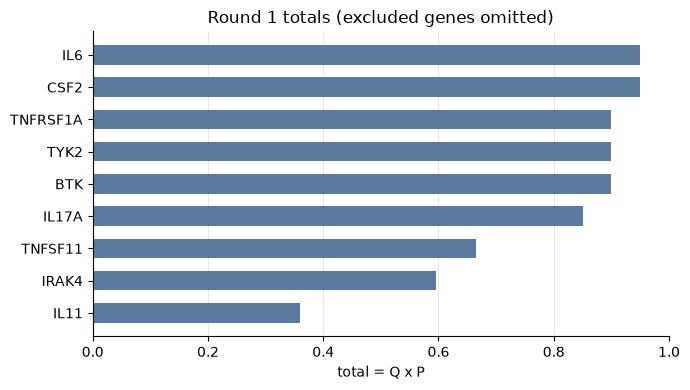

In [9]:
import matplotlib.pyplot as plt
t = score_table(cands).dropna(subset=["total"]).sort_values("total")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(t["gene"], t["total"], color="#5b7a9d", height=0.6)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.set_xlim(0, 1); ax.set_xlabel("total = Q x P"); ax.set_title("Round 1 totals (excluded genes omitted)")
ax.grid(axis="x", color="#ddd", linewidth=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## ステップ4：上位どうしの対戦比較（左右を入れ替えて2回）

同点（0.90 が3つ）の候補に差をつけます。左右で答えが変わった対戦は引き分けにします。

In [10]:
ranked1 = sorted([c for c in cands.values() if c.total is not None and not c.is_seed
                  and c.category not in (Category.KNOWN, Category.EXCLUDED)], key=lambda c: (-c.total, c.symbol))
top4 = [c.symbol for c in ranked1[:rules.pairwise_topk]]
ranking, duel_log = pairwise_rank(top4, loop.compare)
display(pd.DataFrame(duel_log))
print("ranking:", ranking_string(ranking))
for sym, _ in ranking[:3]:
    loop.critic(cands[sym]); print(f"critic {sym}: " + " / ".join(cands[sym].critique))
top5_round1 = [c.symbol for c in ranked1[:rules.stop_topk]]
print("top-5 for stop rule:", top5_round1)

,a,b,first,swapped,verdict
0,CSF2,BTK,CSF2,BTK,tie
1,CSF2,TNFRSF1A,TNFRSF1A,TNFRSF1A,TNFRSF1A
2,CSF2,TYK2,CSF2,CSF2,CSF2
3,BTK,TNFRSF1A,TNFRSF1A,TNFRSF1A,TNFRSF1A
4,BTK,TYK2,BTK,BTK,BTK
5,TNFRSF1A,TYK2,TNFRSF1A,TNFRSF1A,TNFRSF1A


ranking: TNFRSF1A > BTK ≒ CSF2 > TYK2
critic TNFRSF1A: Several TNF-blocking drugs already exist, so demonstrating added value over them is difficult. / Receptor blockade may not be superior to ligand neutralisation. / TNFR1 signalling also mediates host defence.
critic BTK: BTK is expressed in platelets as well as B cells, so bleeding risk exists. / Oral BTK inhibitors have shown mixed efficacy in RA trials. / Off-target kinase effects.
critic CSF2: Its role may be redundant with other cytokines, so blocking it alone may give a small effect. / Phase 3 anti-GM-CSF antibodies have shown insufficient efficacy. / Pulmonary alveolar proteinosis is a theoretical risk.
top-5 for stop rule: ['CSF2', 'BTK', 'TNFRSF1A', 'TYK2', 'IL17A']


## ステップ5：2回目のループ（新しい候補は ×0.7）

1回目で検証を通った候補を新しい種にして広げます。

In [11]:
sources2 = [c.symbol for c in new1 if c.category != Category.EXCLUDED]
new2 = loop.expand(sources2, cands, round_no=2, known=known)
for c in new2:
    loop.annotate(c, seeds); loop.verify(c)
    score_candidate(c, CHAIN, seed_stages, rules, loop.qids)
print("new in round 2:", [c.symbol for c in new2])
ranked2 = sorted([c for c in cands.values() if c.total is not None and not c.is_seed
                  and c.category not in (Category.KNOWN, Category.EXCLUDED)], key=lambda c: (-c.total, c.symbol))
top5_round2 = [c.symbol for c in ranked2[:rules.stop_topk]]
print("top-5 round 1:", top5_round1)
print("top-5 round 2:", top5_round2)
print("stop?", set(top5_round1) == set(top5_round2))
score_table(cands)

new in round 2: ['MYD88', 'CSF2RA', 'IL6ST']
top-5 round 1: ['CSF2', 'BTK', 'TNFRSF1A', 'TYK2', 'IL17A']
top-5 round 2: ['CSF2', 'BTK', 'TNFRSF1A', 'TYK2', 'IL17A']
stop? True


,gene,round,stage,dir,M,N,V,Q1,Q2,Q3,Q4,Q5,Q,P,total,category,note
0,CSF2,1,S4,worse,1.0,0.5,0.5,1.00,1.00,1.0,1.00,0.25,0.95,1.0,0.9500,moa_near,
1,IL6,1,S4,worse,1.0,1.0,1.0,1.00,1.00,1.0,1.00,0.25,0.95,1.0,0.9500,known,"olokizumab (approved in some countries, e.g. R..."
2,BTK,1,S2,worse,1.0,0.5,0.5,0.75,1.00,1.0,1.00,0.25,0.90,1.0,0.9000,moa_near,
3,TNFRSF1A,1,S4,worse,1.0,1.0,0.5,1.00,1.00,1.0,1.00,0.50,0.90,1.0,0.9000,moa_near,
4,TYK2,1,S5,worse,1.0,1.0,1.0,0.75,1.00,1.0,1.00,0.25,0.90,1.0,0.9000,moa_near,
5,IL17A,1,S4,worse,1.0,0.5,0.5,0.75,0.75,1.0,1.00,0.25,0.85,1.0,0.8500,moa_near,
6,CSF2RA,2,S4,worse,1.0,0.0,0.5,1.00,1.00,1.0,1.00,0.25,0.95,1.0,0.6650,moa_near,
7,TNFSF11,1,S6,worse,0.7,0.5,0.0,1.00,1.00,1.0,1.00,0.25,0.95,0.7,0.6650,known,denosumab (Japan: inhibition of bone-erosion p...
8,IRAK4,1,S3,worse,0.7,0.5,0.5,0.75,1.00,1.0,1.00,0.50,0.85,0.7,0.5950,moa_near,
9,IL6ST,2,S4,worse,1.0,1.0,1.0,1.00,1.00,1.0,1.00,1.00,0.80,1.0,0.5600,moa_near,


## ステップ6：4つに分けて、根拠の鎖を付ける

In [12]:
from target_loop.report import CAT_JA
by_cat = {}
for c in sorted(cands.values(), key=lambda c: (-(c.total or 0), c.symbol)):
    by_cat.setdefault(c.category, []).append(c.symbol)
display(pd.DataFrame([{"category": CAT_JA[k], "genes": ", ".join(v)} for k, v in by_cat.items()]))
for c in ranked2:
    print(f"{c.symbol:9s} {c.how_found}; stage {c.stage} ({c.direction.value})")

,category,genes
0,しくみ（MoA）が近い候補,"CSF2, BTK, TNFRSF1A, TYK2, IL17A, CSF2RA, IRAK..."
1,既知（直接の関連が確認された）,"IL6, CD80, IL6R, JAK1, MS4A1, TNF, TNFSF11"
2,地図（ベクトル）が近い候補,IL11
3,別枠（逆向き・矛盾）,IL10


CSF2      TNF -> same stage S4 -> CSF2; stage S4 (worse)
BTK       MS4A1 -> same stage S2 -> BTK; stage S2 (worse)
TNFRSF1A  TNF -> direct partner -> TNFRSF1A; stage S4 (worse)
TYK2      JAK1 -> direct partner -> TYK2; stage S5 (worse)
IL17A     TNF -> same stage S4 -> IL17A; stage S4 (worse)
CSF2RA    CSF2 -> direct partner -> CSF2RA; stage S4 (worse)
IRAK4     TNF -> upstream regulator -> IRAK4; stage S3 (worse)
IL6ST     IL6 -> direct partner -> IL6ST; stage S4 (worse)
IL11      IL6R -> map neighbour (same family) -> IL11; stage None (worse)
MYD88     IRAK4 -> upstream regulator -> MYD88; stage S3 (worse)


## まとめて実行（上の手順を `TargetLoop.run` が自動で行う）

同じ結果になることを確認します。

In [13]:
from IPython.display import Markdown
loop_auto = TargetLoop(RecordedBackend(build_record()) if MODEL_PATH is None else backend, CHAIN, rules)
res = loop_auto.run(SEEDS_PROPOSED)
auto_ranking = [c.symbol for c in res.ranked()]
manual_ranking = [c.symbol for c in ranked2]
print("same ranking as manual steps:", auto_ranking == manual_ranking)
print("stop reason:", res.stop_reason)
Markdown(to_markdown(res))

same ranking as manual steps: True
stop reason: round 2: top-5 unchanged


# rheumatoid arthritis: training-free target loop

seeds: CD80, MS4A1, TNF, IL6R, JAK1  
- seed note: CTLA4: corrected to CD80 (drug abatacept binds CD80, CD86)

## Mechanism chain

| stage | content | seeds |
|---|---|---|
| S1 | antigen presentation and T-cell activation | CD80 |
| S2 | B cells and autoantibodies | MS4A1 |
| S3 | innate immune signalling | ─ |
| S4 | inflammatory cytokines and their receptors | TNF, IL6R |
| S5 | intracellular signalling (JAK-STAT) | JAK1 |
| S6 | synovial proliferation and osteoclast activation | ─ |
| S7 | joint destruction (symptom) | ─ |

## Scores

| gene | round | found via | stage | dir | M | N | V | Q1 | Q2 | Q3 | Q4 | Q5 | Q | P | total | category |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| CSF2 | 1 | TNF -> same stage S4 -> CSF2 | S4 | worse | 1.0 | 0.5 | 0.5 | 1.00 | 1.00 | 1.00 | 1.00 | 0.25 | 0.95 | 1.00 | **0.95** | moa_near |
| IL6 | 1 | IL6R -> direct partner -> IL6 | S4 | worse | 1.0 | 1.0 | 1.0 | 1.00 | 1.00 | 1.00 | 1.00 | 0.25 | 0.95 | 1.00 | **0.95** | known |
| BTK | 1 | MS4A1 -> same stage S2 -> BTK | S2 | worse | 1.0 | 0.5 | 0.5 | 0.75 | 1.00 | 1.00 | 1.00 | 0.25 | 0.90 | 1.00 | **0.90** | moa_near |
| TNFRSF1A | 1 | TNF -> direct partner -> TNFRSF1A | S4 | worse | 1.0 | 1.0 | 0.5 | 1.00 | 1.00 | 1.00 | 1.00 | 0.50 | 0.90 | 1.00 | **0.90** | moa_near |
| TYK2 | 1 | JAK1 -> direct partner -> TYK2 | S5 | worse | 1.0 | 1.0 | 1.0 | 0.75 | 1.00 | 1.00 | 1.00 | 0.25 | 0.90 | 1.00 | **0.90** | moa_near |
| IL17A | 1 | TNF -> same stage S4 -> IL17A | S4 | worse | 1.0 | 0.5 | 0.5 | 0.75 | 0.75 | 1.00 | 1.00 | 0.25 | 0.85 | 1.00 | **0.85** | moa_near |
| CSF2RA | 2 | CSF2 -> direct partner -> CSF2RA | S4 | worse | 1.0 | 0.0 | 0.5 | 1.00 | 1.00 | 1.00 | 1.00 | 0.25 | 0.95 | 1.00 | **0.66** | moa_near |
| TNFSF11 | 1 | TNF -> downstream effector -> TNFSF11 | S6 | worse | 0.7 | 0.5 | 0.0 | 1.00 | 1.00 | 1.00 | 1.00 | 0.25 | 0.95 | 0.70 | **0.66** | known |
| IRAK4 | 1 | TNF -> upstream regulator -> IRAK4 | S3 | worse | 0.7 | 0.5 | 0.5 | 0.75 | 1.00 | 1.00 | 1.00 | 0.50 | 0.85 | 0.70 | **0.59** | moa_near |
| IL6ST | 2 | IL6 -> direct partner -> IL6ST | S4 | worse | 1.0 | 1.0 | 1.0 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 | 0.80 | 1.00 | **0.56** | moa_near |
| IL11 | 1 | IL6R -> map neighbour (same family) -> IL11 | ─ | worse | 0.0 | 0.5 | 1.0 | 0.50 | 0.50 | 0.50 | 1.00 | 0.50 | 0.60 | 0.60 | **0.36** | map_near |
| MYD88 | 2 | IRAK4 -> upstream regulator -> MYD88 | S3 | worse | 0.7 | 0.0 | 0.5 | 0.75 | 1.00 | 1.00 | 0.25 | 0.75 | 0.65 | 0.70 | **0.32** | moa_near |
| IL10 | 1 | TNF -> same stage S4 -> IL10 | S4 | better | 0.0 | 0.5 | 0.5 | 1.00 | 1.00 | 0.00 | 1.00 | 0.50 | ─ | 0.40 | **─** | excluded – opposite direction (inhibition expected to worsen disease) |

## Round 1

sources: CD80, MS4A1, TNF, IL6R, JAK1  
new candidates: BTK, TNFRSF1A, IRAK4, TNFSF11, CSF2, IL17A, IL10, IL6, IL11, TYK2  

| duel | first | swapped | verdict |
|---|---|---|---|
| CSF2 vs BTK | CSF2 | BTK | tie |
| CSF2 vs TNFRSF1A | TNFRSF1A | TNFRSF1A | TNFRSF1A |
| CSF2 vs TYK2 | CSF2 | CSF2 | CSF2 |
| BTK vs TNFRSF1A | TNFRSF1A | TNFRSF1A | TNFRSF1A |
| BTK vs TYK2 | BTK | BTK | BTK |
| TNFRSF1A vs TYK2 | TNFRSF1A | TNFRSF1A | TNFRSF1A |

pairwise ranking: **TNFRSF1A > BTK ≒ CSF2 > TYK2**  
top-5 for stop rule: CSF2, BTK, TNFRSF1A, TYK2, IL17A

## Round 2

sources: BTK, TNFRSF1A, IRAK4, TNFSF11, CSF2, IL17A, IL6, IL11, TYK2  
new candidates: MYD88, CSF2RA, IL6ST  

| duel | first | swapped | verdict |
|---|---|---|---|
| CSF2 vs BTK | CSF2 | BTK | tie |
| CSF2 vs TNFRSF1A | TNFRSF1A | TNFRSF1A | TNFRSF1A |
| CSF2 vs TYK2 | CSF2 | CSF2 | CSF2 |
| BTK vs TNFRSF1A | TNFRSF1A | TNFRSF1A | TNFRSF1A |
| BTK vs TYK2 | BTK | BTK | BTK |
| TNFRSF1A vs TYK2 | TNFRSF1A | TNFRSF1A | TNFRSF1A |

pairwise ranking: **TNFRSF1A > BTK ≒ CSF2 > TYK2**  
top-5 for stop rule: CSF2, BTK, TNFRSF1A, TYK2, IL17A

stop reason: round 2: top-5 unchanged

## Categories

| category | genes |
|---|---|
| 既知（直接の関連が確認された） | IL6, CD80, IL6R, JAK1, MS4A1, TNF, TNFSF11 |
| しくみ（MoA）が近い候補 | CSF2, BTK, TNFRSF1A, TYK2, IL17A, CSF2RA, IRAK4, IL6ST, MYD88 |
| 地図（ベクトル）が近い候補 | IL11 |
| 別枠（逆向き・矛盾） | IL10 |

## Critic notes (top 3)

- **CSF2**: Its role may be redundant with other cytokines, so blocking it alone may give a small effect. / Phase 3 anti-GM-CSF antibodies have shown insufficient efficacy. / Pulmonary alveolar proteinosis is a theoretical risk.
- **BTK**: BTK is expressed in platelets as well as B cells, so bleeding risk exists. / Oral BTK inhibitors have shown mixed efficacy in RA trials. / Off-target kinase effects.
- **TNFRSF1A**: Several TNF-blocking drugs already exist, so demonstrating added value over them is difficult. / Receptor blockade may not be superior to ligand neutralisation. / TNFR1 signalling also mediates host defence.

## Evidence chains

- CSF2: TNF -> same stage S4 -> CSF2; stage S4 (worse); verification: no approved drug for this indication
- BTK: MS4A1 -> same stage S2 -> BTK; stage S2 (worse); verification: no approved drug for this indication
- TNFRSF1A: TNF -> direct partner -> TNFRSF1A; stage S4 (worse); verification: no approved drug for this indication
- TYK2: JAK1 -> direct partner -> TYK2; stage S5 (worse); verification: no approved drug for this indication
- IL17A: TNF -> same stage S4 -> IL17A; stage S4 (worse); verification: no approved drug for this indication
- CSF2RA: CSF2 -> direct partner -> CSF2RA; stage S4 (worse); verification: no approved drug for this indication
- IRAK4: TNF -> upstream regulator -> IRAK4; stage S3 (worse); verification: no approved drug for this indication
- IL6ST: IL6 -> direct partner -> IL6ST; stage S4 (worse); verification: no approved drug for this indication
- IL11: IL6R -> map neighbour (same family) -> IL11; stage ─ (worse); verification: no approved drug for this indication
- MYD88: IRAK4 -> upstream regulator -> MYD88; stage S3 (worse); verification: no approved drug for this indication


## 検証1：減衰0.7と停止ルールは混ざっている

2回目の候補の総合点は最大 0.7。1回目の上位5件の最低点（0.85）を超えられないので、停止は定数の帰結です。
減衰を変えると回数が変わることを確かめます（記録にない対戦は引き分け扱い）。

In [14]:
from dataclasses import replace
from demo.ra_demo import run as run_demo
rows = []
for d in (0.5, 0.7, 0.9, 1.0):
    r, _ = run_demo(replace(rules, round_damping=d), lenient_pairwise=True)
    rows.append({"damping": d, "rounds": len(r.rounds), "stop": r.stop_reason,
                 "round-2 genes in top-5": ", ".join(g for g in r.rounds[-1].top_set if r.candidates[g].round_found == 2) or "─",
                 "ranking": " > ".join(c.symbol for c in r.ranked())})
pd.DataFrame(rows)

,damping,rounds,stop,round-2 genes in top-5,ranking
0,0.5,2,round 2: top-5 unchanged,─,CSF2 > BTK > TNFRSF1A > TYK2 > IL17A > IRAK4 >...
1,0.7,2,round 2: top-5 unchanged,─,CSF2 > BTK > TNFRSF1A > TYK2 > IL17A > CSF2RA ...
2,0.9,3,round 3: no new candidates,CSF2RA,CSF2 > BTK > TNFRSF1A > TYK2 > CSF2RA > IL17A ...
3,1.0,3,round 3: no new candidates,CSF2RA,CSF2 > CSF2RA > BTK > TNFRSF1A > TYK2 > IL17A ...


## 検証2：ヒト遺伝学の質問（Q6）を足すと順位はどう変わるか

デモの反省点「最上位の CSF2 は第3相で失敗した」に対する改善案です。Q6 の値は Claude の判断（未検証）です。

In [15]:
r6, _ = run_demo(replace(rules, use_genetics_question=True), lenient_pairwise=True)
pd.DataFrame({"Q1-Q5": [c.symbol for c in res.ranked()], "Q1-Q6": [c.symbol for c in r6.ranked()]})

,Q1-Q5,Q1-Q6
0,CSF2,TYK2
1,BTK,CSF2
2,TNFRSF1A,BTK
3,TYK2,TNFRSF1A
4,IL17A,IL17A
5,CSF2RA,CSF2RA
6,IRAK4,IRAK4
7,IL6ST,IL6ST
8,IL11,IL11
9,MYD88,MYD88


## （任意）TxGemma の「はい」確率と Claude の判定を比べる

`MODEL_PATH` に GGUF を指定した場合だけ実行されます。13遺伝子 × 5問 × 6回の forward pass を行います。

In [16]:
if MODEL_PATH and os.path.exists(MODEL_PATH):
    rows = []
    for g, conf in ANSWERS.items():
        for qid in ("Q1", "Q2", "Q3", "Q4", "Q5"):
            rows.append({"gene": g, "qid": qid, "claude": conf[int(qid[1]) - 1], "model": loop.ask(qid, g)})
    cmp = pd.DataFrame(rows)
    print("Pearson r:", round(cmp["claude"].corr(cmp["model"]), 3))
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(cmp["claude"], cmp["model"], s=40, color="#5b7a9d", alpha=0.7)
    ax.plot([0, 1], [0, 1], color="#999", linewidth=1, linestyle="--")
    ax.set_xlabel("Claude confidence"); ax.set_ylabel("model p_yes"); ax.set_title("per question")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    plt.tight_layout(); plt.show()
    display(cmp.pivot(index="gene", columns="qid", values="model").round(2))
else:
    print("MODEL_PATH が未指定のためスキップ。GGUF を指定して、バックエンド選択のセルから再実行してください。")

MODEL_PATH が未指定のためスキップ。GGUF を指定して、バックエンド選択のセルから再実行してください。
